### Supervised Learning

Supervised learning is a type of machine learning where the algorithm learns from labeled data, consisting of input-output pairs. In supervised learning, you train the algorithm on a dataset that includes input features and corresponding correct output labels. The goal is for the algorithm to learn the mapping or relationship between the input features and the output labels. This enables it to make predictions or decisions on new, unseen data.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_03/Image_1.png)

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_03/Image_2.png)

__Regression__

Regression types can be classified into two categories: linear and non-linear.

**Linear Regression**

Definition: Linear regression finds a straight-line relationship between the dependent variable and one or more independent variables.

**Non-Linear Regression**

Definition: Non-linear regression finds a relationship between the dependent variable and independent variables using a curve or a more complex shape.


![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_04/Linear.png)

In [ ]:
#### Step 1: Import the Required Libraries
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Read the dataset `tvmarketing.csv`.
data=pd.read_csv("tvmarketing.csv")

# Display a summary of the DataFrame, including the column names, non-null count, and data types
print("The info on the data is :\n")
info = data.info()
#print(type(info))

#Check if there are no null objects.

#### Step 2: Fit the Linear Regression Model
'''
- Now, let's define the features and the target variables.
- Here, X(independent variable) is assigned to all the rows in the first column of the dataset.
- y(dependent variable) is assigned to all the rows of the second column of the same dataset.
'''

# Extract the feature(s) from the DataFrame
#X=data.iloc[:,0:1].values
X = data.iloc[:,0].values.reshape(-1,1)
#print(X)
# Extract the target variable from the DataFrame
y=data.iloc[:,1].values

#print(y)

"""
**Perform train-test split**

Train-test split is a technique in machine learning used to evaluate a model's
performance by dividing the data into two parts: a training set and a test set.
The model is trained on the training set, learning patterns and parameters,
and then evaluated on the test set to see how well it generalizes to new, unseen data.

**Note:** This train-test data split will be used for other implementations as well.
"""

# Import train_test_split function from sklearn's model_selection module
from sklearn.model_selection import train_test_split


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#print(X_train)
#print(X_test)
#print(y_train)
#print(y_test)

# Import the LinearRegression class from scikit-learn's linear_model module
from sklearn.linear_model import LinearRegression
# Create an instance of the LinearRegression class
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

def viz_linear():
    plt.scatter(X_test, lin_reg.predict(X_test), color='green')  # X_test should represent TV expenses
    plt.plot(X_train, lin_reg.predict(X_train), color='blue')  # X_train is TV expenses, predicted values are Sales
    plt.title('Linear Regression Model (Test set)')
    plt.xlabel('TV')  # Independent variable (TV)
    plt.ylabel('Sales')  # Dependent variable (Sales)
    plt.legend(['Test Data', 'Trained Data'])
    plt.show()
#viz_linear()

#check for overfitting or underfitting of the model

# Import necessary libraries for performance metrics
from sklearn.metrics import mean_squared_error, r2_score


# Predicting for the training set

y_train_pred = lin_reg.predict(X_train)
#y_train_pred = pd.DataFrame(y_train_pred)
#print(y_train_pred.describe())

# Predicting for the test set
y_test_pred = lin_reg.predict(X_test)
#y_test_pred = pd.DataFrame(y_test_pred)
#print(y_test_pred.describe())

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
'''
 - MSE measures the average of the squares of the errors, that is, the average
   squared difference between the estimated values and the actual value.
 - R² provides an indication of goodness of fit and therefore a measure of how
   well unseen samples are likely to be predicted by the model
'''
# Print the metrics
print("\nTraining Set Mean Squared Error:", mse_train)
print("Test Set Mean Squared Error:", mse_test)
print("Training Set R² Score:", r2_train)
print("Test Set R² Score:", r2_test)
print("------------------------------------------")

The info on the data is :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB

Training Set Mean Squared Error: 11.189103289351676
Test Set Mean Squared Error: 8.970991242413614
Training Set R² Score: 0.5736021199591975
Test Set R² Score: 0.6714477229302764
------------------------------------------


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#Read the dataset `tvmarketing.csv`.
data=pd.read_csv("tvmarketing.csv")

# Display a summary of the DataFrame, including the column names, non-null count, and data types
print("The info on the data is :\n")
info = data.info()


x = data.iloc[:,0].values.reshape(-1,1)
y = data.iloc[:,1].values

# Correctly assign the output of train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size = 0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(x_train,y_train)

def viz_linear():
    plt.scatter(x_test, y_test, color='green')  # X_test should represent TV expenses
    plt.plot(x_train, lin_reg.predict(x_train), color='blue')  # X_train is TV expenses, predicted values are Sales
    plt.title('Linear Regression Model (Test set)')
    plt.xlabel('TV')  # Independent variable (TV)
    plt.ylabel('Sales')  # Dependent variable (Sales)
    plt.legend(['Test Data', 'Trained Data'])
    plt.show()
#viz_linear() #optional

y_train_pred = lin_reg.predict(x_train)
y_test_pred = lin_reg.predict(x_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\nTraining Set Mean Squared Error:", mse_train)
print("Test Set Mean Squared Error:", mse_test)
print("\nTraining Set R² Score:", r2_train)
print("Test Set R² Score:", r2_test)

## from the Statistical data, the model is not fit(the R square is >0.6 and mse is higer)
#so ploynomial regression is used to alter the x_test and x_train values.

from sklearn.preprocessing import PolynomialFeatures
poly_feature = PolynomialFeatures(degree = 4)

x_train_poly = poly_feature.fit_transform(x_train)
x_test_poly = poly_feature.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

y_train_poly_pred = poly_model.predict(x_train_poly)
y_test_poly_pred = poly_model.predict(x_test_poly)

mse_train_poly = mean_squared_error(y_train, y_train_poly_pred)
mse_test_poly = mean_squared_error(y_test, y_test_poly_pred)
r2_train_poly = r2_score(y_train, y_train_poly_pred)
r2_test_poly = r2_score(y_test, y_test_poly_pred)

print("\nTraining Set Mean Squared Error after using PolynomialFeatures:", mse_train_poly)
print("Test Set Mean Squared Error after using PolynomialFeatures:", mse_test_poly)

print("\nTraining Set R² Score after using PolynomialFeatures:", r2_train_poly)
print("Test Set R² Score after using PolynomialFeatures:", r2_test_poly)

The info on the data is :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB

Training Set Mean Squared Error: 11.963784656083853
Test Set Mean Squared Error: 10.174468290309424

Training Set R² Score: 0.5718617819030117
Test Set R² Score: 0.6213181732230723

Training Set Mean Squared Error after using PolynomialFeatures: 10.956836678543295
Test Set Mean Squared Error after using PolynomialFeatures: 10.537869235630556

Training Set R² Score after using PolynomialFeatures: 0.6078966091097476
Test Set R² Score after using PolynomialFeatures: 0.607792814462287


**Build a linear regression model, perform analysis on it, and evaluate the model's performance:**

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


# Load the dataset
housing_data = pd.read_csv('housing_with_ocean_proximity.csv')

# Display summary statistics for the DataFrame 'housing_df'
print(housing_data.describe())
print(housing_data.info())
print(housing_data.isna().sum())

#Since the null values makes up for only 1% of the total data,
#rows of the column/feature with missing values will be removed

# Remove all the rows with null values
housing_data = housing_data.dropna()
# Recheck for missing values in the DataFrame 'housing_df'
housing_data.isna().sum()

#create dummy variable for object data
housing_data = pd.get_dummies(housing_data, drop_first=True, dtype='int',prefix='op')
housing_data.head()

#Assign values to X and y
X = housing_data.drop(['median_house_value'], axis=1)
y = housing_data['median_house_value']

# Splitting the data into training and testing sets to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

#Implement K-fold cross-validation.
# Divides the dataset into 10 folds.
kf = KFold(n_splits=10, random_state=42, shuffle=True)

#using Linear regression model
model = LinearRegression()

'''
**Evaluate the model**

- cross_val_score: Evaluates the model using cross-validation.
- model: The machine learning model to evaluate.
- X_train and y_train: Training features and target variables.
- scoring='neg_mean_absolute_error': Uses negative MAE as the performance metric.
- cv=kf: Cross-validation strategy (e.g., KFold).
- n_jobs=-1: Utilizes all available processors for parallel computation.
'''
k_fold_scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_absolute_error', cv=kf, n_jobs=-1)

print("The score of the training data is : ",np.mean(np.abs(k_fold_scores)))

# Evaluate the model on the test set
model.fit(X_train, y_train)
y_test_pred = model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
print("\nTest MSE: ",test_mse)

# Calculate R-squared score
test_r2 = r2_score(y_test, y_test_pred)
print("\nTest R-squared:",test_r2)

# add the train score as well.
# compute RMSE instead of MSE

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

### Supervised Learning: Classification


Classification is a supervised machine learning technique where the model is trained to predict the class label of a given input data. It looks for the decision boundary, which divides the dataset into different classes.


Types of Classification

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Classification_Part_1/image_1.jpg)

Binary Classification

Binary classification is the most simple type of classification, where the model predicts one of two possible outcomes. For example, yes or no, true or false, spam or not spam.

df.head():

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst

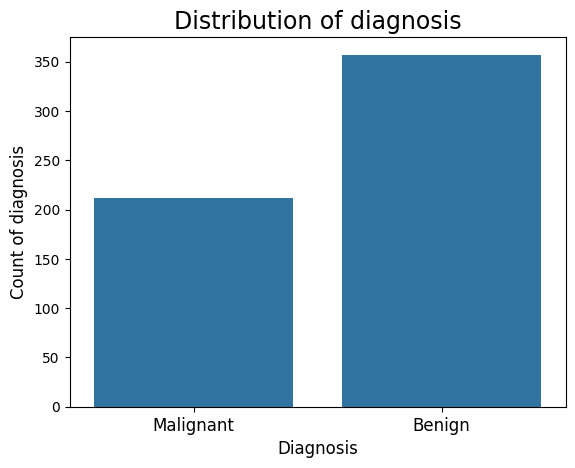

diagnosis
B    357
M    212
Name: count, dtype: int64


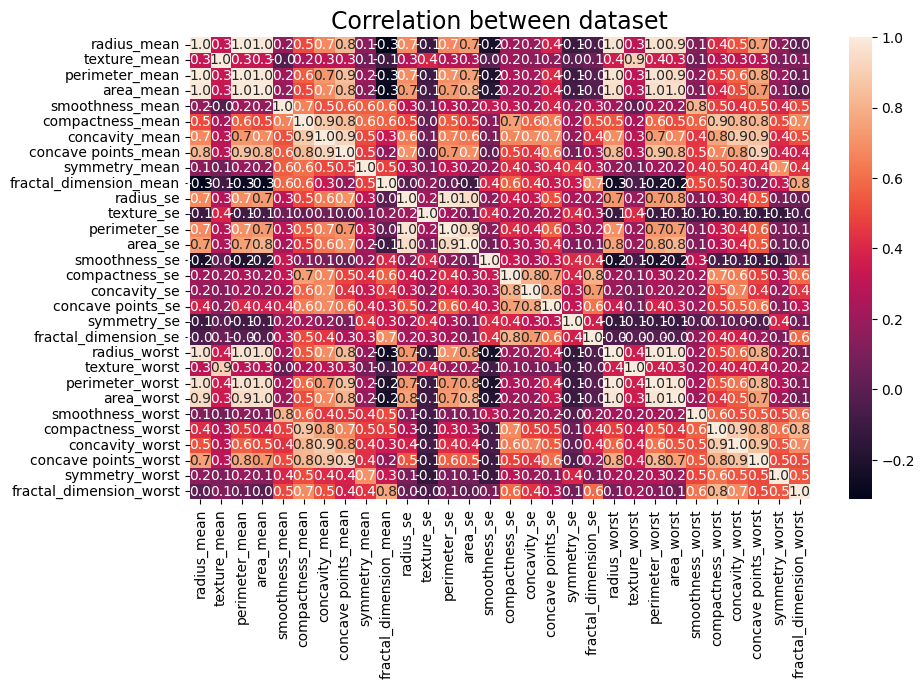

Logistic Regression
Training Accuracy: 0.9868131868131869
Testing Accuracy: 0.9736842105263158


In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
df = pd.read_csv('Breast_cancer_dataset.csv')
# Display the first few rows of the dataset
print("df.head():\n")
print(df.head())

print("\ndf.info():\n")#data information
df.info()
# Summary statistics
print("\ndf.describe():\n")
print(df.describe())
# Check for missing values
print("\ndf.isnull().sum():\n")
df.isnull().sum()

#There are no null/missing values in the dataset

# Distribution of the target variable
sns.countplot(x="diagnosis",data=df)
plt.title("Distribution of diagnosis",fontsize=17,c="k")
plt.xlabel("Diagnosis",fontsize=12)
plt.ylabel("Count of diagnosis",fontsize=12)
plt.xticks([0, 1], ['Malignant','Benign'], fontsize=12)
plt.show()

print(df["diagnosis"].value_counts())

# Remove unwanted columns from the dataset
df=df.drop(["Unnamed: 32", "id"],axis=1)
#df

# Correlation heatmap
#The heatmap visualizes the correlation between different features
#in the dataset, helping identify highly correlated pairs.
plt.figure(figsize=(10,6))
c=df.corr(numeric_only=True)
sns.heatmap(c,annot=True,fmt=".1f")
plt.title("Correlation between dataset",fontsize=17,c="k")
plt.show()

# darker the heatmap, lower the correlation and vice-versa

# Convert Categorical variable diagnosis into one-hot encoded numerical variable
# with benign instances assigned 0 and malignant 1

# Transform diagnosis column into numeric

Encoder=LabelEncoder()
df["diagnosis"]=Encoder.fit_transform(df["diagnosis"])
df["diagnosis"]

## Split data into feature(x) and target(y)
x = df.drop("diagnosis",axis=1)
y = df["diagnosis"]

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define the pipeline
#sklearn.pipeline to streamline the preprocessing and training process
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=10000, random_state=42))
])

# Fit the pipeline on the training data
pipeline.fit(x_train, y_train)

# Predict on the training and testing set
y_pred_train_log_reg = pipeline.predict(x_train)
y_pred_test_log_reg = pipeline.predict(x_test)

# Predict probabilities on the testing set
y_pred_test_prob_log_reg = pipeline.predict_proba(x_test)[:, 1]

results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_log_reg,
    'Predicted Probability': y_pred_test_prob_log_reg
})

# Display the first 5 instances in the result dataframe
results_df.head()

# Calculate the training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_log_reg)
testing_accuracy = accuracy_score(y_test, y_pred_test_log_reg)

print("Logistic Regression")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

Naive Bayes Classifier


- Naive Bayes is a probabilistic classifier based on Bayes' Theorem. Naive Bayes is called naive because it assumes that the input variables are independent of each other. This is a strong assumption and unrealistic for real data.

- It is particularly suited for large datasets and is widely used for binary and multi-class classification tasks.

- It is widely used for text classification, sentiment analysis, etc.

df.head():

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst

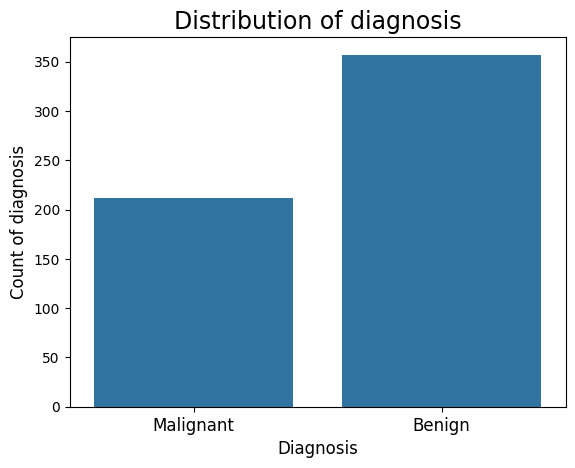

diagnosis
B    357
M    212
Name: count, dtype: int64


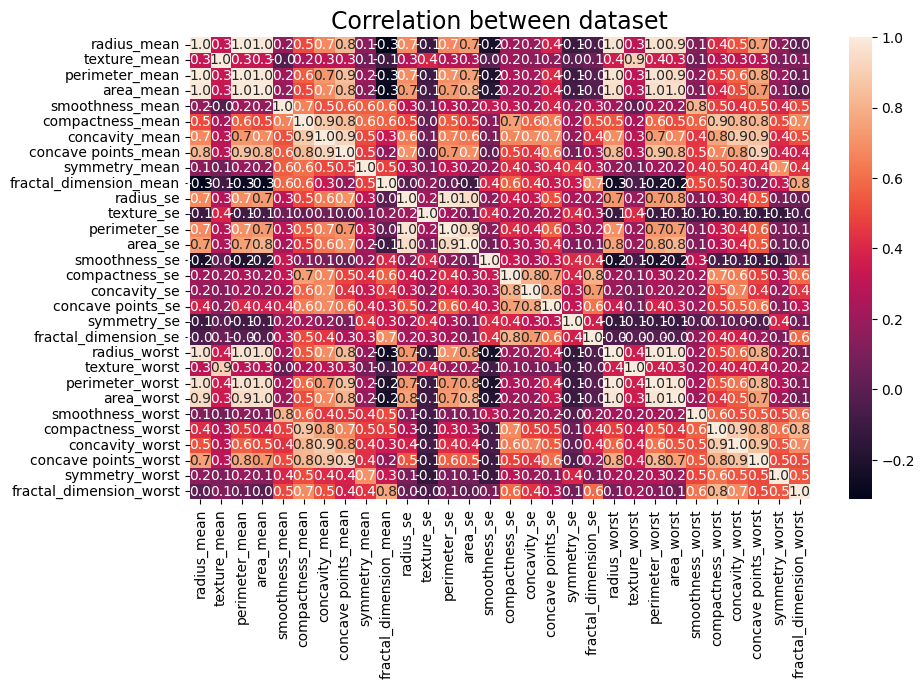

Logistic Regression
Training Accuracy: 0.9362637362637363
Testing Accuracy: 0.9649122807017544


In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Import Required Libraries and apply Naive Bayes algorithm
from sklearn.naive_bayes import GaussianNB

# Load the Breast Cancer dataset
df = pd.read_csv('Breast_cancer_dataset.csv')
# Display the first few rows of the dataset
print("df.head():\n")
print(df.head())

print("\ndf.info():\n")#data information
df.info()
# Summary statistics
print("\ndf.describe():\n")
print(df.describe())
# Check for missing values
print("\ndf.isnull().sum():\n")
df.isnull().sum()

#There are no null/missing values in the dataset

# Distribution of the target variable
sns.countplot(x="diagnosis",data=df)
plt.title("Distribution of diagnosis",fontsize=17,c="k")
plt.xlabel("Diagnosis",fontsize=12)
plt.ylabel("Count of diagnosis",fontsize=12)
plt.xticks([0, 1], ['Malignant','Benign'], fontsize=12)
plt.show()

print(df["diagnosis"].value_counts())

# Remove unwanted columns from the dataset
df=df.drop(["Unnamed: 32", "id"],axis=1)
#df

# Correlation heatmap
#The heatmap visualizes the correlation between different features
#in the dataset, helping identify highly correlated pairs.
plt.figure(figsize=(10,6))
c=df.corr(numeric_only=True)
sns.heatmap(c,annot=True,fmt=".1f")
plt.title("Correlation between dataset",fontsize=17,c="k")
plt.show()

# darker the heatmap, lower the correlation and vice-versa

# Convert Categorical variable diagnosis into one-hot encoded numerical variable
# with benign instances assigned 0 and malignant 1

# Transform diagnosis column into numeric

Encoder=LabelEncoder()
df["diagnosis"]=Encoder.fit_transform(df["diagnosis"])
df["diagnosis"]

## Split data into feature(x) and target(y)
x = df.drop("diagnosis",axis=1)
y = df["diagnosis"]

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define the pipeline
#sklearn.pipeline to streamline the preprocessing and training process
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

# Fit the pipeline on the training data
pipeline.fit(x_train, y_train)

# Predict on the training and testing set
y_pred_train_log_reg = pipeline.predict(x_train)
y_pred_test_log_reg = pipeline.predict(x_test)

# Predict probabilities on the testing set
y_pred_test_prob_log_reg = pipeline.predict_proba(x_test)[:, 1]

results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_log_reg,
    'Predicted Probability': y_pred_test_prob_log_reg
})

# Display the first 5 instances in the result dataframe
results_df.head()

# Calculate the training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_log_reg)
testing_accuracy = accuracy_score(y_test, y_pred_test_log_reg)

print("Logistic Regression")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

K-Nearest Neighbors (KNN)

The K-Nearest Neighbor (KNN) algorithm is a popular machine learning technique used for classification and regression tasks. It relies on the idea that similar data points tend to have similar labels or values.

During the training phase, the KNN algorithm retains the entire training dataset as a reference. For predictions, it computes the distance between the input data point and all training examples using a selected distance metric, such as Euclidean distance, as illustrated in the diagram below:

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_05/KNN.png)

**The following is a step-by-step approach to KNN algorithm:**


**Step 1:** Load the training and test data.

**Step 2:** Choose the value of K, which represents the number of nearest neighbors to consider. (K can be any positive integer)

**Note:** The optimal value for K will depend on the specific dataset and the problem being solved. It's often determined through cross-validation.

**Step 3:** For every point in the test data, do the following:

- Calculate the distance between the test data point and each point in the training dataset using a distance metric such as Euclidean, Manhattan, or Hamming distance.
- Sort the calculated distances in ascending order.
- Select the top K closest data points (smallest distances) from the sorted list.
- Assign the most frequent class (mode) among these K nearest neighbors to the test data point.

df.head():

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst

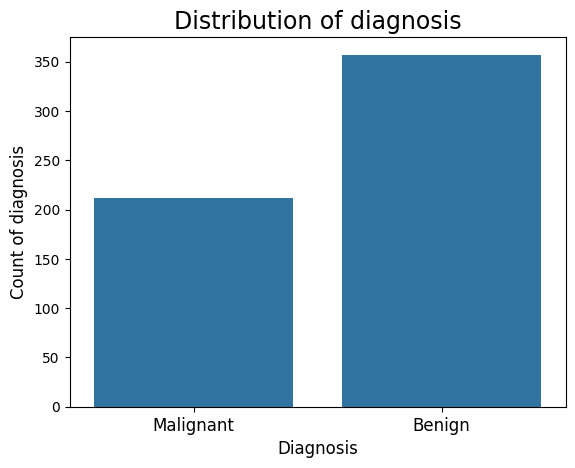

diagnosis
B    357
M    212
Name: count, dtype: int64


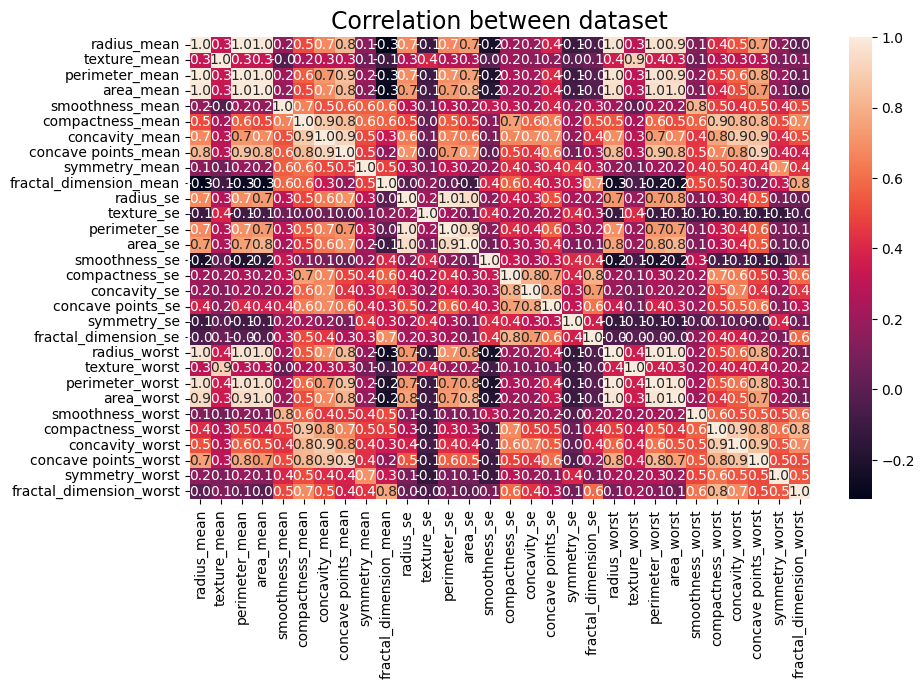


K-Nearest Neighbors (KNN)
Training Accuracy: 0.978021978021978
Testing Accuracy: 0.9649122807017544
Confusion Matrix:
[[69  2]
 [ 2 41]]


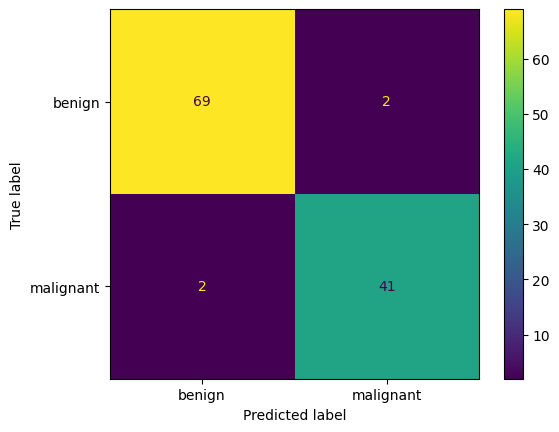

		K-Nearest Neighbors Classification Report:
		-----------------------------------
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Import Required Libraries and apply K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

# Load the Breast Cancer dataset
df = pd.read_csv('Breast_cancer_dataset.csv')
# Display the first few rows of the dataset
print("df.head():\n")
print(df.head())

print("\ndf.info():\n")#data information
df.info()
# Summary statistics
print("\ndf.describe():\n")
print(df.describe())
# Check for missing values
print("\ndf.isnull().sum():\n")
df.isnull().sum()

#There are no null/missing values in the dataset

# Distribution of the target variable
sns.countplot(x="diagnosis",data=df)
plt.title("Distribution of diagnosis",fontsize=17,c="k")
plt.xlabel("Diagnosis",fontsize=12)
plt.ylabel("Count of diagnosis",fontsize=12)
plt.xticks([0, 1], ['Malignant','Benign'], fontsize=12)
plt.show()

print(df["diagnosis"].value_counts())

# Remove unwanted columns from the dataset
df=df.drop(["Unnamed: 32", "id"],axis=1)
#df

# Correlation heatmap
#The heatmap visualizes the correlation between different features
#in the dataset, helping identify highly correlated pairs.
plt.figure(figsize=(10,6))
c=df.corr(numeric_only=True)
sns.heatmap(c,annot=True,fmt=".1f")
plt.title("Correlation between dataset",fontsize=17,c="k")
plt.show()

# darker the heatmap, lower the correlation and vice-versa

# Convert Categorical variable diagnosis into one-hot encoded numerical variable
# with benign instances assigned 0 and malignant 1

# Transform diagnosis column into numeric

Encoder=LabelEncoder()
df["diagnosis"]=Encoder.fit_transform(df["diagnosis"])
df["diagnosis"]

## Split data into feature(x) and target(y)
x = df.drop("diagnosis",axis=1)
y = df["diagnosis"]

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),   # Standardize the data
    ('knn', KNeighborsClassifier(n_neighbors=9)) # KNN classifier
])
pipeline_knn.fit(x_train, y_train)

# Predict on the training and testing set
y_pred_train_knn = pipeline_knn.predict(x_train)
y_pred_test_knn = pipeline_knn.predict(x_test)

# Calculate training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_knn)
testing_accuracy = accuracy_score(y_test, y_pred_test_knn)
print("\nK-Nearest Neighbors (KNN)")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

y_pred_prob_knn = pipeline_knn.predict_proba(x_test)[:, 1]

results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_knn,
    'Predicted Probability': y_pred_prob_knn
})

results_df.head()

len(results_df[(results_df["Actual Label"] == 1) & (results_df["Predicted Label"] == 1)])

# Print confusion matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred_test_knn)
print("Confusion Matrix:")
print(conf_matrix_knn)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix_knn, display_labels = ["benign", "malignant"])
# display matrix
cm_display.plot()
plt.show()

# Print classification report
print("\t\tK-Nearest Neighbors Classification Report:")
print("\t\t-----------------------------------")
print(classification_report(y_test, y_pred_test_knn))

Decision Tree

A decision tree is a non-parametric supervised learning algorithm for classification and regression tasks.
- It has a hierarchical tree structure consisting of a root node, branches, internal nodes, and leaf nodes.
- Decision trees are used for classification and regression tasks, providing easy-to-understand models.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_05/5.02node.png)

Example: The following decision tree diagram represents the criteria for buying a car based on its color, model year, and mileage.
![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_05/DT.png)

df.head():

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst

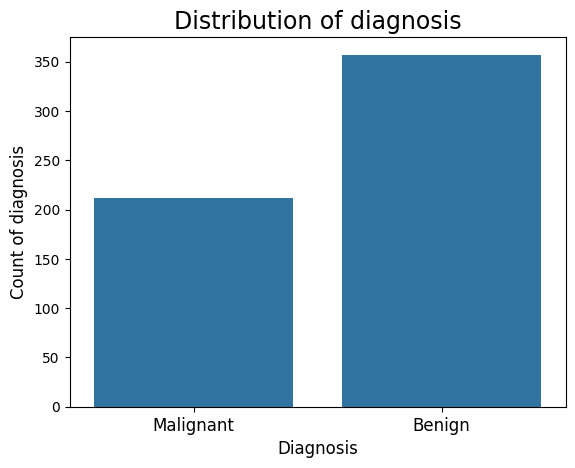

diagnosis
B    357
M    212
Name: count, dtype: int64


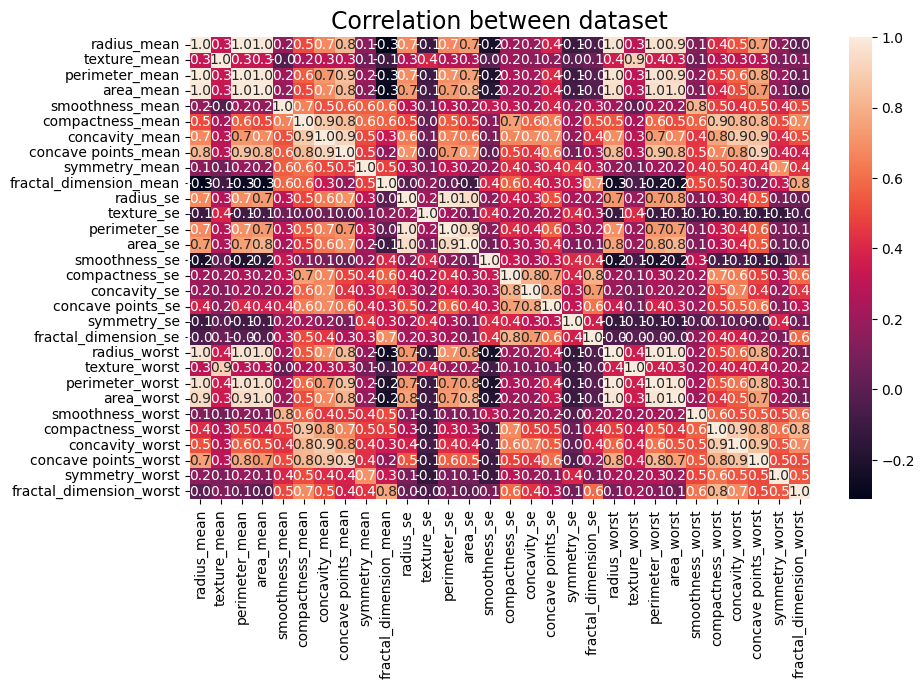


Decision Trees
Training Accuracy: 1.0
Testing Accuracy: 0.9385964912280702


In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
#Import Required Libraries and apply decision tree
from sklearn.tree import DecisionTreeClassifier
# Load the Breast Cancer dataset
df = pd.read_csv('Breast_cancer_dataset.csv')
# Display the first few rows of the dataset
print("df.head():\n")
print(df.head())

print("\ndf.info():\n")#data information
df.info()
# Summary statistics
print("\ndf.describe():\n")
print(df.describe())
# Check for missing values
print("\ndf.isnull().sum():\n")
df.isnull().sum()

#There are no null/missing values in the dataset

# Distribution of the target variable
sns.countplot(x="diagnosis",data=df)
plt.title("Distribution of diagnosis",fontsize=17,c="k")
plt.xlabel("Diagnosis",fontsize=12)
plt.ylabel("Count of diagnosis",fontsize=12)
plt.xticks([0, 1], ['Malignant','Benign'], fontsize=12)
plt.show()

print(df["diagnosis"].value_counts())

# Remove unwanted columns from the dataset
df=df.drop(["Unnamed: 32", "id"],axis=1)
#df

# Correlation heatmap
#The heatmap visualizes the correlation between different features
#in the dataset, helping identify highly correlated pairs.
plt.figure(figsize=(10,6))
c=df.corr(numeric_only=True)
sns.heatmap(c,annot=True,fmt=".1f")
plt.title("Correlation between dataset",fontsize=17,c="k")
plt.show()

# darker the heatmap, lower the correlation and vice-versa

# Convert Categorical variable diagnosis into one-hot encoded numerical variable
# with benign instances assigned 0 and malignant 1

# Transform diagnosis column into numeric

Encoder=LabelEncoder()
df["diagnosis"]=Encoder.fit_transform(df["diagnosis"])
df["diagnosis"]

## Split data into feature(x) and target(y)
x = df.drop("diagnosis",axis=1)
y = df["diagnosis"]

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),   # Standardize the data
    ('dt', DecisionTreeClassifier()) # Decision Tree classifier
])
pipeline.fit(x_train, y_train)

# Predict on the training and testing set
y_pred_train_dt = pipeline.predict(x_train)
y_pred_test_dt = pipeline.predict(x_test)

# Calculate training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_dt)
testing_accuracy = accuracy_score(y_test, y_pred_test_dt)
print("\nDecision Trees")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

y_pred_prob_dt = pipeline.predict_proba(x_test)[:, 1]

results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_dt,
    'Predicted Probability': y_pred_prob_dt
})

Support Vector Machine (SVM)

It is a supervised machine-learning algorithm used for both classification and regression challenges. It is mainly utilized for classification-related problems.

* In support vector machine, the required straight line to fit the data is called the hyperplane.
* The goal of the Support Vector Machine algorithm is to find a hyperplane in an n-dimensional space that distinctly classifies the data points.
* The closest data points to the hyperplane on either side are called Support Vectors.
* These support vectors influence the position and orientation of the hyperplane, aiding in the construction of the SVM.


![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_05/SVM.png)

df.head():

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst

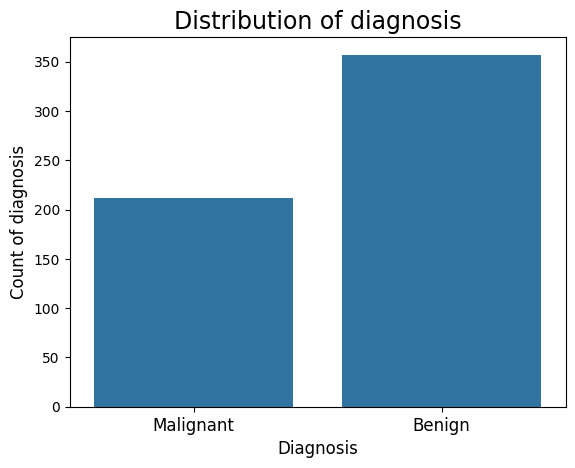

diagnosis
B    357
M    212
Name: count, dtype: int64


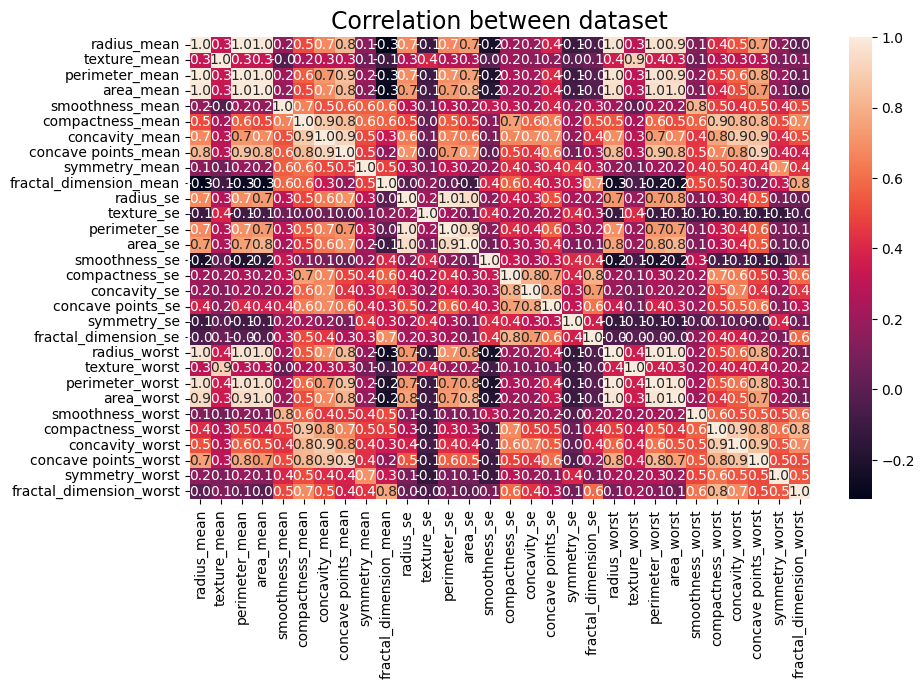


Support Vector Machines (SVM)
Training Accuracy: 0.989010989010989
Testing Accuracy: 0.9824561403508771


,Actual Label,Predicted Label,Predicted Probability
204,0,0,0.020564
70,1,1,1.000000
131,1,1,0.999992
431,0,0,0.000158
540,0,0,0.000062


In [ ]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Import necessary libraries
from sklearn.svm import SVC

# Load the Breast Cancer dataset
df = pd.read_csv('Breast_cancer_dataset.csv')
# Display the first few rows of the dataset
print("df.head():\n")
print(df.head())

print("\ndf.info():\n")#data information
df.info()
# Summary statistics
print("\ndf.describe():\n")
print(df.describe())
# Check for missing values
print("\ndf.isnull().sum():\n")
df.isnull().sum()

#There are no null/missing values in the dataset

# Distribution of the target variable
sns.countplot(x="diagnosis",data=df)
plt.title("Distribution of diagnosis",fontsize=17,c="k")
plt.xlabel("Diagnosis",fontsize=12)
plt.ylabel("Count of diagnosis",fontsize=12)
plt.xticks([0, 1], ['Malignant','Benign'], fontsize=12)
plt.show()

print(df["diagnosis"].value_counts())

# Remove unwanted columns from the dataset
df=df.drop(["Unnamed: 32", "id"],axis=1)
#df

# Correlation heatmap
#The heatmap visualizes the correlation between different features
#in the dataset, helping identify highly correlated pairs.
plt.figure(figsize=(10,6))
c=df.corr(numeric_only=True)
sns.heatmap(c,annot=True,fmt=".1f")
plt.title("Correlation between dataset",fontsize=17,c="k")
plt.show()

# darker the heatmap, lower the correlation and vice-versa

# Convert Categorical variable diagnosis into one-hot encoded numerical variable
# with benign instances assigned 0 and malignant 1

# Transform diagnosis column into numeric

Encoder=LabelEncoder()
df["diagnosis"]=Encoder.fit_transform(df["diagnosis"])
df["diagnosis"]

## Split data into feature(x) and target(y)
x = df.drop("diagnosis",axis=1)
y = df["diagnosis"]

# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create a pipeline with a standard scaler and an SVM classifier
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),  # Standardize the data
    ('svm', SVC(probability=True, random_state=42))  # SVM classifier with probability estimates
])

# Train the pipeline on the training data
pipeline_svm.fit(x_train, y_train)

# Predict on the training and testing set
y_pred_train_svm = pipeline_svm.predict(x_train)
y_pred_test_svm = pipeline_svm.predict(x_test)

# Calculate training and testing accuracy
training_accuracy = accuracy_score(y_train, y_pred_train_svm)
testing_accuracy = accuracy_score(y_test, y_pred_test_svm)
print("\nSupport Vector Machines (SVM)")
print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

# Predict probabilities for the test set
y_pred_prob_svm = pipeline_svm.predict_proba(x_test)[:, 1]

results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_pred_test_svm,
    'Predicted Probability': y_pred_prob_svm
})

results_df.head()

Ensemble Learning

Ensemble learning combines multiple models to enhance the overall performance of machine learning algorithms. The fundamental principle of ensemble learning is combining predictions from multiple individual models to produce a more accurate and robust prediction than any single model.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_07/ensemble_learning.png)

Sequential Ensemble Technique

the training data divided into four samples, with each sample trained on a distinct base model. Insights gained from model M1 are passed to model M2 alongside sample S2. M2 then adjusts its weights and biases based on the outcomes of M1. This process repeats for models 2, 3, and 4. Finally, all the learners are combined using a weighted averaging strategy.

The summation sign ( ∑ ) indicates the function that adjusts the model to improve its overall performance.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_07/Sequential_Ensemble_Technique.png)


Parallel Ensemble Technique

the training data is divided into four samples, labeled S1 to S4, each trained on a distinct base model (M1 to M4). Unlike the sequential ensemble technique, the data in the base learners is independent. This independence of base learners significantly reduces the error due to the application of averages.
![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_07/Parallel_Ensemble_Technique.png)

Voting

Voting is one of the fundamental methods of ensemble learning. It involves aggregating the predictions from multiple models to arrive at a final prediction. Two common types of voting in ensemble learning are:

Majority voting/Hard voting
Weighted voting/Soft voting.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report## statistical outcomes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay#so
from sklearn.impute import SimpleImputer#replaci gthe NULL value
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score#regression algo -> so
from sklearn.linear_model import LogisticRegression#ML model
from sklearn.tree import DecisionTreeClassifier#ML model
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier#EL model
from sklearn import model_selection#packaging
from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_val_score

# Load the dataset from the specified URL and assign column names to the DataFrame
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data', header=None)
data.columns = ['Sample code', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
                'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
                'Normal Nucleoli', 'Mitoses', 'Class']

data.head()

# Drop the 'Sample code' column as it's not required for prediction
data.drop(['Sample code'], axis=1, inplace=True)

# Replace '?' with nan to handle missing data, ensuring numerical analysis accuracy and preventing calculation errors.
data = data.replace('?', np.nan)
# Convert the 'Bare Nuclei' column to an integer type to ensure a uniform data type across the column,
# which is essential for consistent data manipulation and analysis.
data['Bare Nuclei'] = pd.to_numeric(data['Bare Nuclei']).fillna(0).astype('int64')
data.head()

# Replace class values to be binary (2 for benign, 4 for malignant)
data['Class'] = data['Class'].replace({2: 0, 4: 1})
# Display information about the dataset
data.info()

# Extract features (X) and target variable (y)
X = data.iloc[:, :-1]  # All columns except the last one
y = data.iloc[:, -1]   # Last column as the target variable

# Perform a train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

# Create an instance of SimpleImputer to fill in missing values with the median
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Create an instance of MinMaxScaler to scale features to a range of (0, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Initialize list for base models
estimators = [
    ('logistic', LogisticRegression()),
    ('cart', DecisionTreeClassifier()),
    ('svm', SVC())
]

# Create Voting Classifier ensemble with estimators
ensemble = VotingClassifier(estimators, voting="hard")

# Set up KFold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=7)

# Evaluate ensemble model using cross-validation
results = cross_val_score(ensemble, X_train_scaled, y_train, cv=kfold)

# Print mean accuracy score of the ensemble model
print(f"Mean cross-validation accuracy of the ensemble model: {results.mean():.2f}")

# Fit the ensemble on the scaled training set and evaluate on the scaled test set
ensemble.fit(X_train_scaled, y_train)
test_accuracy = ensemble.score(X_test_scaled, y_test)

# Print test accuracy
print(f"Test accuracy of the ensemble model: {test_accuracy:.2f}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clump Thickness              699 non-null    int64
 1   Uniformity of Cell Size      699 non-null    int64
 2   Uniformity of Cell Shape     699 non-null    int64
 3   Marginal Adhesion            699 non-null    int64
 4   Single Epithelial Cell Size  699 non-null    int64
 5   Bare Nuclei                  699 non-null    int64
 6   Bland Chromatin              699 non-null    int64
 7   Normal Nucleoli              699 non-null    int64
 8   Mitoses                      699 non-null    int64
 9   Class                        699 non-null    int64
dtypes: int64(10)
memory usage: 54.7 KB
Mean cross-validation accuracy of the ensemble model: 0.96
Test accuracy of the ensemble model: 0.96


 Bagging

 Bagging or Bootstrap Aggregating enhances the stability and accuracy of machine learning algorithms. This method creates multiple subsets from the original dataset, known as bootstrap samples, by selecting data points with replacement. Each subset trains a separate model.

For final predictions, Bagging combines the individual models' outputs by using voting (for classification tasks) or averaging (for regression tasks). This approach effectively reduces variance and helps prevent overfitting.

Note: Random Forest is a popular algorithm that utilizes bagging by training multiple decision trees on different bootstrap samples and combining their predictions.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_05/Ensembled_Learning_Bagging.png)

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn import model_selection#fol EL
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold #iteration
from sklearn.ensemble import GradientBoostingClassifier#
from sklearn.ensemble import BaggingClassifier#for bagging
from sklearn.tree import DecisionTreeClassifier#ML model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report#Statistical Outcome
from sklearn.metrics import accuracy_score#Statistical Outcome
from sklearn.preprocessing import StandardScaler#data processing
from sklearn.preprocessing import MinMaxScaler

# Load the Pima Indians Diabetes dataset using the given URL and assign the names

url="https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = pd.read_csv(url, names=names)

# Check the head of the data using the head() method
data.head()

# Assign all the rows up to the 8th column of the data to X
X = data.iloc[:,0:8].values

# Assign the 9th column of the same data to Y
y = data["class"].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create an instance of SimpleImputer to fill in missing values with the median
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Create an instance of MinMaxScaler to scale features to a range of (0, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Set up the k-fold cross-validation with n_splits to 10
kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=1)

# Create a decision tree classifier named cart
cart = DecisionTreeClassifier()

# The estimator will be set to 100, which is equal to the number of trees
num_trees = 100

# Create a bagging classifier with the decision tree classifier (cart) as the base estimator
# Ensure oob_score is enabled
bagging_model = BaggingClassifier(estimator=cart, n_estimators=num_trees, random_state=12, oob_score=True)

# Perform cross-validation using the model, feature matrix (X), target vector (y), and specified number of folds (cv)
results = model_selection.cross_val_score(bagging_model, X_train_scaled, y_train, cv=kfold)

# Print the cross-validation results
print(results)

# Calculate the Mean Cross-Validation Score using .mean() function
mean_score = np.mean(results)

print("Mean Cross-Validation Score:", mean_score)

[0.79032258 0.67741935 0.75806452 0.70967742 0.86885246 0.78688525
 0.63934426 0.7704918  0.73770492 0.72131148]
Mean Cross-Validation Score: 0.7460074034902168


 Boosting

 Boosting is a sequential ensemble technique where each model corrects its predecessor's mistakes. The main idea is to train models sequentially, each trying to correct the errors of the previous model.

The final prediction is a weighted sum of all the models' predictions. Boosting significantly reduces bias and variance, leading to more accurate models.

Note: Popular boosting algorithms include AdaBoost, Gradient Boosting Machines (GBM), and XGBoost.


![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/updated/Lesson_05/Ensembled_Learning_Boosting.png)

AdaBoost Algorithm

AdaBoost, an abbreviation for adaptive boosting, stands as one of the leading boosting algorithms with widespread adoption. It focuses on classification problems, aiming to transform a collection of weak classifiers into a single strong classifier. It increases the weights of misclassified instances, directing subsequent classifiers to pay more attention to challenging cases.

The AdaBoost algorithm follows these steps:
1. Initially, the algorithm assigns equal weights to all observations in the dataset.
2. A model is constructed using a subset of the data.
3. Predictions are made on the entire dataset using this model.
4. The algorithm computes errors by comparing these predictions to the actual values.
5. In the subsequent model creation, the algorithm assigns higher weights to incorrectly predicted data points.
6. Weights are determined based on error values, where higher errors result in heavier observation weights.
7. This iterative process continues until the error function stabilizes or the algorithm reaches the maximum limit of estimators.

AdaBoost Classifier mean accuracy:  0.9534740259740259
Adaboost Classifier test accuracy:  0.9571428571428572
___________________________Adaboost Classifier_______________________

# Classification report
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        91
           1       0.96      0.92      0.94        49

    accuracy                           0.96       140
   macro avg       0.96      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140

# Confusion matrix


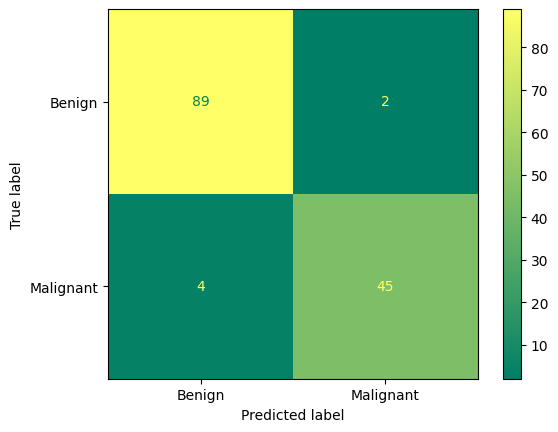

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load the dataset from the given URL and assign column names
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data', header=None)
data.columns = ['Sample code', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape',
                'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin',
                'Normal Nucleoli', 'Mitoses','Class']

# Drop the 'Sample code' column as it's not required for prediction
data.drop(['Sample code'], axis=1, inplace=True)

# Replace '?' with nan to handle missing data, ensuring numerical analysis accuracy and preventing calculation errors.
data = data.replace('?', np.nan)

# Replace class values to be binary (2 for benign, 4 for malignant)
data['Class'] = data['Class'].replace({2: 0, 4: 1})

# Convert the 'Bare Nuclei' column to an integer type to ensure a uniform data type across the column,
# which is essential for consistent data manipulation and analysis.
data['Bare Nuclei'] = pd.to_numeric(data['Bare Nuclei']).fillna(0).astype('int64')

# Split data into features (X) and target variable (y)
X = data.drop('Class', axis=1)
y = data['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

# Define K-fold cross-validation
kfold = KFold(n_splits=10, random_state=7, shuffle=True)

# Create a pipeline for AdaBoost classifier with Decision Tree base estimator
adaboost_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler(feature_range=(0, 1))),
    ('classifier', AdaBoostClassifier(n_estimators=70, random_state=7))
])

# Evaluate the Adaboost Classifier pipeline using cross-validation on the training set
adaboost_results = cross_val_score(adaboost_pipeline, X_train, y_train, cv=kfold)
print("AdaBoost Classifier mean accuracy: ", adaboost_results.mean())


# Fit the Adaboost Classifier pipeline on the training set and evaluate on the test set
adaboost_pipeline.fit(X_train, y_train)
adaboost_test_score = adaboost_pipeline.score(X_test, y_test)
print("Adaboost Classifier test accuracy: ", adaboost_test_score)

# fitting  and evaluating Boosting classifier model in training and test dataset

print('___________________________Adaboost Classifier_______________________')
print()
# evaluating model on test dataset
y_pred = adaboost_pipeline.predict(X_test)
print('# Classification report')
print(classification_report(y_test,y_pred))
print('# Confusion matrix')
cmap = 'summer'
display_labels=['Benign','Malignant']
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(cmap=cmap)
plt.show()

### Unsupervised Learning

- Unsupervised learning is a machine learning type where the model learns from unlabeled data to find patterns within it.
- It deals with unlabeled datasets.
- It enables algorithms to work independently to discover hidden information or pattern in the data without guidance.
- It classifies unsorted information according to patterns, differences, or similarities.


### K-Means Clustering

K-means clustering is an unsupervised machine learning algorithm that partitions data into k clusters by minimizing the within-cluster variance.

- It groups unlabeled data into clusters by identifying the k number of centroids.
- It assigns every data point to the closest cluster by calculating and using the pairwise Euclidean distance between points.

![link text](https://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_06/Updated/new/Unsupervised.png)

__Elbow method to find the optimal K__

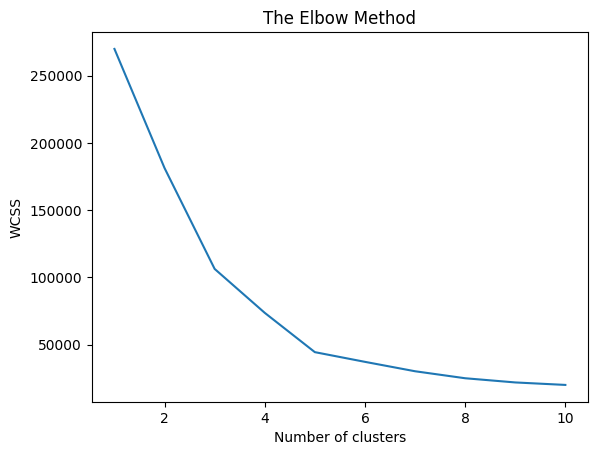

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


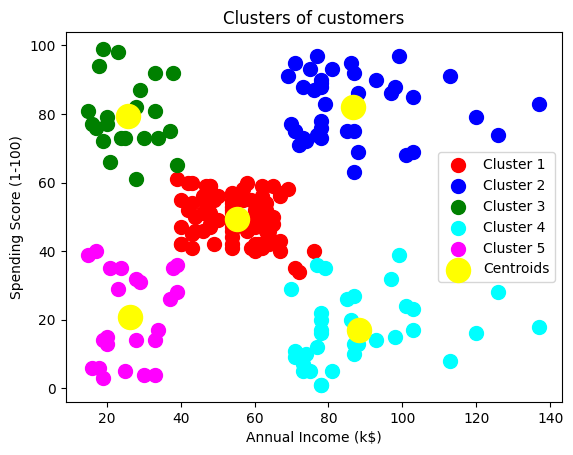

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv('Mall_customers.csv')

df.head()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters = i, n_init=10, init = 'k-means++', random_state = 42)
    model.fit(X)
    wcss.append(model.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

model = KMeans(n_clusters = 5, n_init = 10, init = 'k-means++', random_state = 42)
y_kmeans = model.fit_predict(X)

print(y_kmeans)

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In the plotted graph, identify where the WCSS graph starts to flatten out. The plot flattens at 5. Hence this number is chosen as the Optimal `k`


- K-means clusters with K = 5.

**Interpretation of Each Cluster**

Cluster 1 (Red):

Positioned at lower annual income and moderate to high spending scores.
This cluster might represent customers who, despite having lower incomes, tend to spend a significant portion of their income.

Cluster 2 (Blue):

Middle to high annual income with the lowest spending scores among all clusters.
These customers are earning a good amount but are conservative in their spending habits.

Cluster 3 (Green):

Lower income and lower spending scores.
Represents a conservative customer group with limited financial flexibility.

Cluster 4 (Cyan):

Higher income and very high spending scores.
These are the premium customers who earn a lot and spend a lot, likely the target for high-end marketing campaigns.

Cluster 5 (Magenta):

High income but moderate spending scores.
Customers in this cluster have high earning potential but do not spend as extravagantly as those in Cluster 4.

__Silhouette Score to find the optimal K__

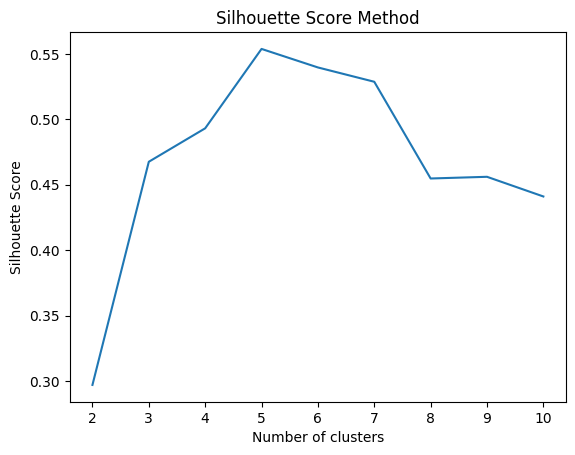

y_kmeans [4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


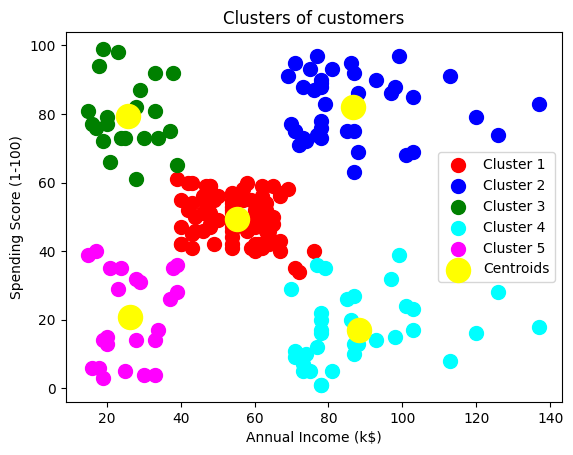

In [3]:
#from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

df = pd.read_csv('Mall_customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Silhouette Score method
silhouette_scores = []
for i in range(2, 11):
    model = KMeans(n_clusters=i, n_init=10,  init='k-means++', random_state=42)
    model.fit(X)
    score = silhouette_score(X, model.labels_)
    silhouette_scores.append(score)

plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Select the number of clusters with the highest silhouette score
optimal_clusters = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]

# Fit the model with the optimal number of clusters
model = KMeans(n_clusters=optimal_clusters, n_init=10, init='k-means++', random_state=42)
y_kmeans = model.fit_predict(X)
print("y_kmeans",y_kmeans)
# Visualize the clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

From the plot, the optimal number of clusters k can be chosen based on the highest Silhouette Score. This score represents a balance between having clusters that are dense and well-separated from each other. Looking at the plot:

The Silhouette Score peaks at `k=5`. This suggests that the clusters are most distinct and appropriately separated when the data is divided into 5 clusters.

K-means clusters with K = 5.

 Implementation of hierarchical clustering.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Text(0, 0.5, 'Distance between clusters')

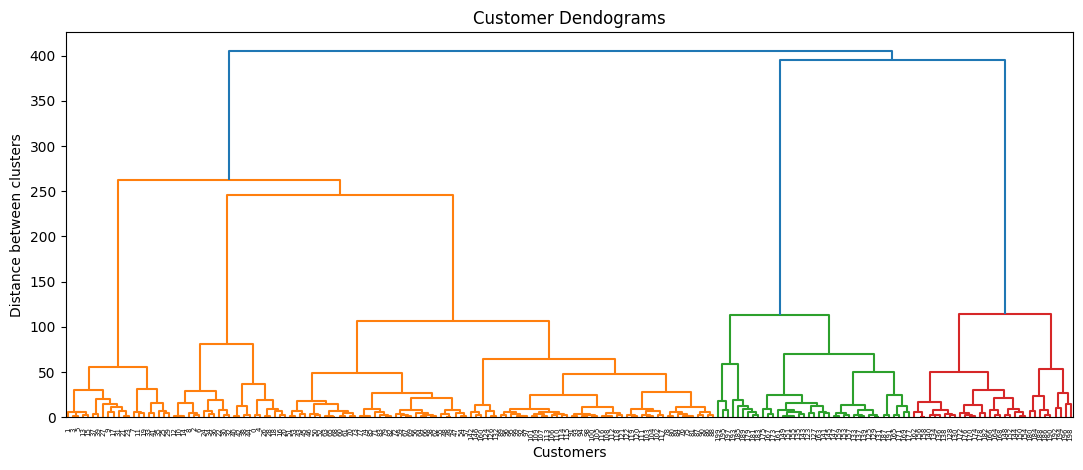

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as shc

df = pd.read_csv('Mall_customers.csv')
df.head()

df.info()
# Choosing the first 50 rows from df to create a new dataframe df1 with relevant features
df1 = df.iloc[:, 3:5].values


plt.figure(figsize=(13, 5))
plt.title("Customer Dendograms")
dend = shc.dendrogram(shc.linkage(df1, method='ward'))
plt.xlabel('Customers')
plt.ylabel('Distance between clusters')

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN is a popular unsupervised machine learning algorithm primarily used for clustering tasks, where the goal is to group closely packed data points based on some notion of distance. It identifies points that are alone in low-density regions as outliers or noise.



   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Estimated number of clusters (train): 2
Estimated number of noise points (train): 75
Estimated number of clusters (test): 2
Estimated number of noise points (test): 58


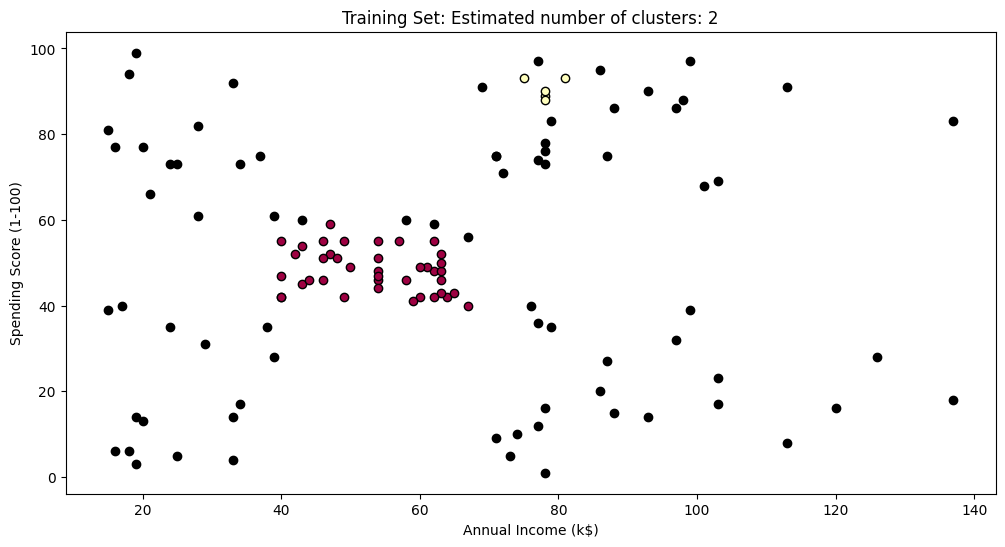

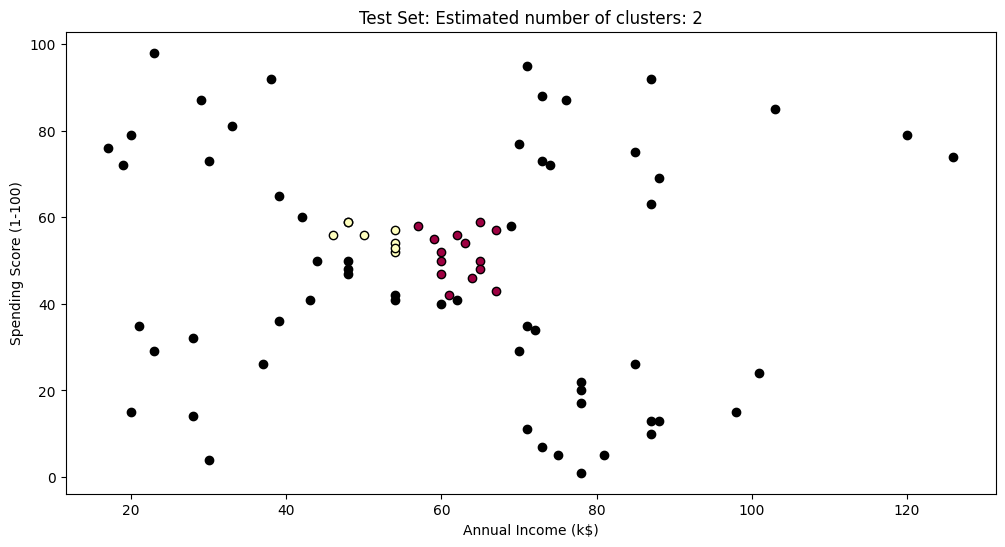

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split

data = pd.read_csv('Mall_customers.csv')

# Display the first few rows of the dataset
print(data.head())

# Select relevant features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values
X_train, X_test = train_test_split(X, test_size=0.4, random_state=42)

# Apply DBSCAN to the training set
db = DBSCAN(eps=5, min_samples=5).fit(X_train)
labels_train = db.labels_

# Apply DBSCAN to the test set
labels_test = db.fit_predict(X_test)

# Number of clusters in labels, ignoring noise if present.
n_clusters_train = len(set(labels_train)) - (1 if -1 in labels_train else 0)
n_noise_train = list(labels_train).count(-1)

n_clusters_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)
n_noise_test = list(labels_test).count(-1)

print(f'Estimated number of clusters (train): {n_clusters_train}')
print(f'Estimated number of noise points (train): {n_noise_train}')
print(f'Estimated number of clusters (test): {n_clusters_test}')
print(f'Estimated number of noise points (test): {n_noise_test}')

# Plot the clusters for training set
unique_labels_train = set(labels_train)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels_train))]

plt.figure(figsize=(12, 6))

for k, col in zip(unique_labels_train, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels_train == k)

    xy = X_train[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)

plt.title(f'Training Set: Estimated number of clusters: {n_clusters_train}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()


# Plot the clusters for test set
unique_labels_test = set(labels_test)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels_test))]

plt.figure(figsize=(12, 6))

for k, col in zip(unique_labels_test, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = (labels_test == k)

    xy = X_test[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title(f'Test Set: Estimated number of clusters: {n_clusters_test}')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

### **Observation:**

The DBSCAN clustering algorithm identified 2 clusters in both the training and test sets, with a significant number of noise points (black dots) spread across the entire feature space. Cluster 1 is positioned around an annual income of 60k and a spending score of 60, while Cluster 2 is centered around an annual income of 60k and a spending score of 40. The presence of these two clusters in both datasets indicates that the clustering is consistent, though the majority of data points are classified as noise.

Recommendation Systems

Recommendation Systems are software tools and algorithms that provide suggestions for products, services, or information to users. The suggestions are tailored to the user’s preferences, based on data about their previous behavior and preferences.

![link text](http://labcontent.simplicdn.net/data-content/content-assets/Data_and_AI/ML/Lesson_07/recommendation_system_edited.png)

Data Expoloration using SMOTE- Synthetic Minority over SAmpling Technique

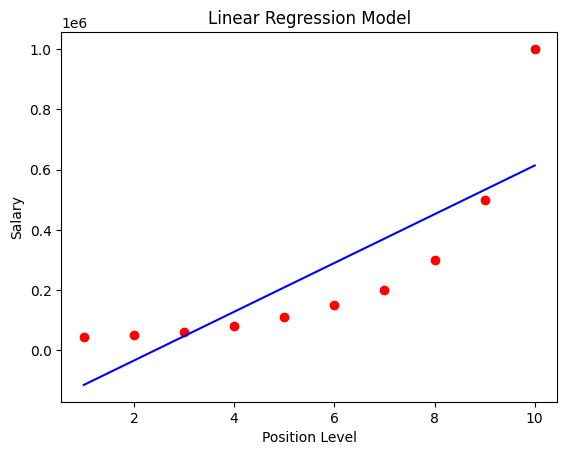

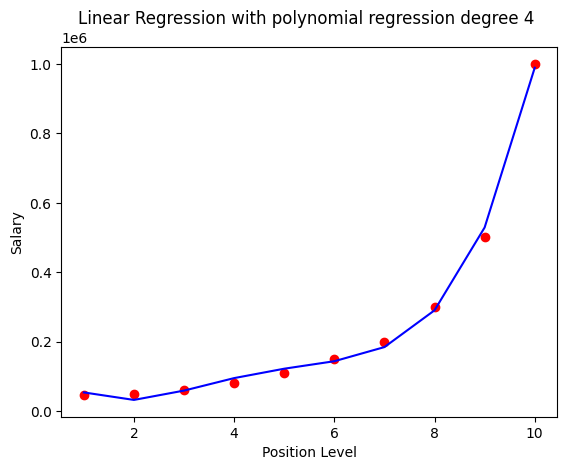

[249500.]
[132148.43750002]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

dataset = pd.read_csv('position_salaries.csv')
dataset.head()

X = dataset.iloc[:, 1:2].values
Y = dataset.iloc[:, 2].values

X_train,X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=32)

lin_reg = LinearRegression()
lin_reg.fit(X, Y)

def viz_linear():
  plt.scatter(X, Y, color='red')
  plt.plot(X, lin_reg.predict(X), color='blue')
  plt.title('Linear Regression Model')
  plt.xlabel('Position Level')
  plt.ylabel('Salary')
  plt.show()
  return

viz_linear()

#The data points do not fit the line and is scattered

poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)
pol_reg = LinearRegression()
pol_reg.fit(X_poly, Y)

def viz_polynomial():
  plt.scatter(X, Y, color='red')
  plt.plot(X, pol_reg.predict(poly_reg.fit_transform(X)), color='blue')
  plt.title('Linear Regression with polynomial regression degree 4 ')
  plt.xlabel('Position Level')
  plt.ylabel('Salary')
  plt.show()
  return

viz_polynomial()

print(lin_reg.predict([[5.5]]))
print(pol_reg.predict(poly_reg.fit_transform([[5.5]])))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


/tmp/ipython-input-2267484755.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  animes['genre'].fillna('Unknown', inplace=True)
/tmp/ipython-input-2267484755.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

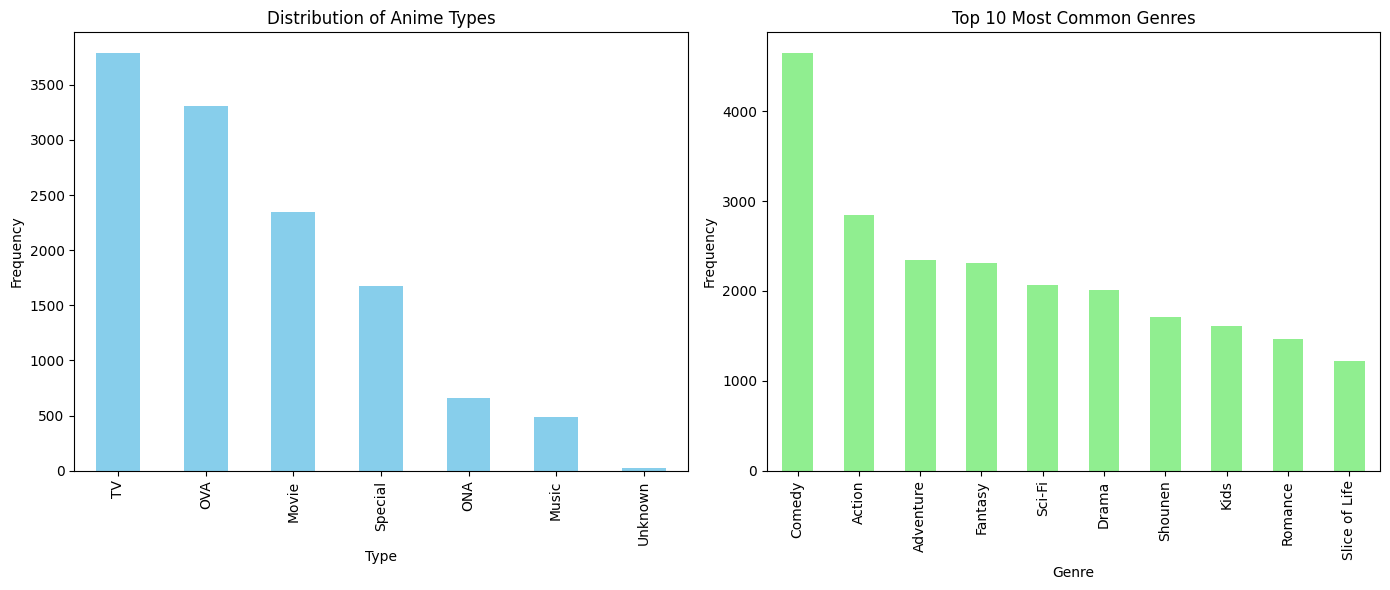

<class 'pandas.core.frame.DataFrame'>
Index: 6337241 entries, 47 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 193.4 MB
6337241
69600
12294
91.05231321839081


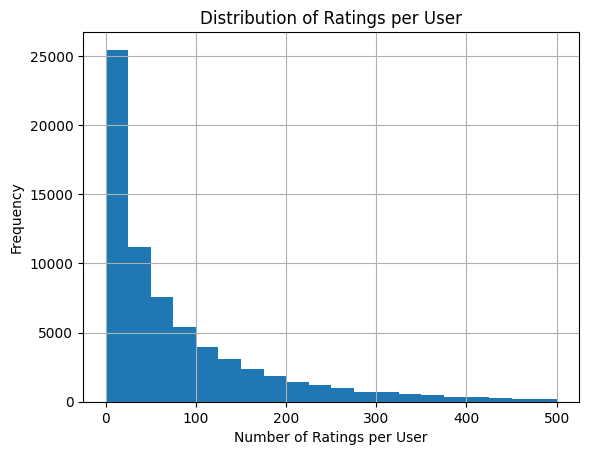

638.3843054296364


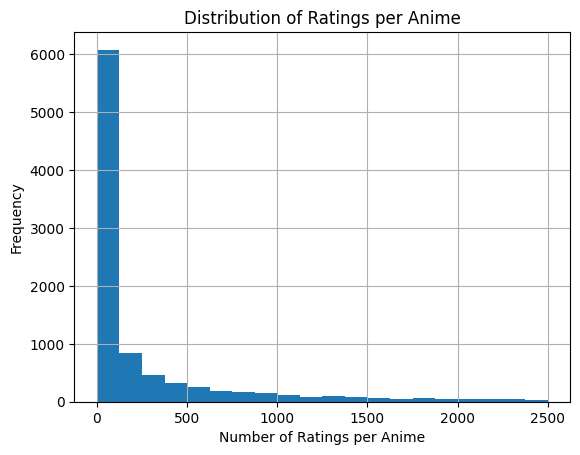

popular_anime 1462
prolific_users 1365
filtered_ratings 1005314
anime_id  1      5      6      7      8      15     16     17     18     \
user_id                                                                   
226         8.0    0.0    8.0    0.0    0.0    0.0    0.0    0.0    0.0   
271         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
294         7.0    7.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
392         7.0    0.0    7.0    0.0    0.0    0.0    0.0    0.0    7.0   
446         9.0    8.0    9.0    0.0    0.0    0.0    0.0    0.0    0.0   

anime_id  19     ...  34238  34239  34240  34252  34283  34324  34325  34349  \
user_id          ...                                                           
226         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
271         0.0  ...    0.0    0.0   10.0    0.0    0.0    0.0    0.0    0.0   
294         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
392       

,anime_id,name,genre,type,episodes,rating,members
6,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148.0,9.13,425855
39,12365,Bakuman. 3rd Season,"Comedy, Drama, Romance, Shounen",TV,25.0,8.71,133620
87,10030,Bakuman. 2nd Season,"Comedy, Drama, Romance, Shounen",TV,25.0,8.53,151561
131,4224,Toradora!,"Comedy, Romance, School, Slice of Life",TV,25.0,8.45,633817
184,7674,Bakuman.,"Comedy, Romance, Shounen",TV,25.0,8.35,246899


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import statistics
import operator

# load the data from 'anime.csv' into a DataFrame named 'animes'.
animes = pd.read_csv('anime.csv')
# Display the first five rows of the DataFrame using the 'head()' method to provide a quick overview of the dataset structure and content.
animes.head()
# Use the 'info()' method to output a concise summary of the DataFrame, including the number of non-null entries in each column, the data type of each column, and memory usage.
animes.info()
# Calculates the total number of missing (null) values in each column using the 'isnull().sum()' method, helping to identify columns that might require cleaning or further investigation due to missing data.
animes.isnull().sum()

# Handle missing values
animes['genre'].fillna('Unknown', inplace=True)
animes['type'].fillna('Unknown', inplace=True)

# Convert the 'episodes' column in the 'animes' dataframe to numeric data type using
# the pd.to_numeric() function, with any non-convertible values replaced by 0
animes['episodes'] = pd.to_numeric(animes['episodes'], errors='coerce').fillna(0)

# Fill missing ratings with mean rating
animes['rating'].fillna(animes['rating'].mean(), inplace=True)

# Generate descriptive statistics for the numerical columns of the 'animes' DataFrame
animes.describe()

# Analyzing categorical variables
type_counts = animes['type'].value_counts()
genre_counts = animes['genre'].str.split(', ').explode().value_counts().head(10)

# Plotting the distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

type_counts.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Anime Types')
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('Type')

genre_counts.plot(kind='bar', ax=ax[1], color='lightgreen')
ax[1].set_title('Top 10 Most Common Genres')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Genre')

plt.tight_layout()
plt.show()

#Exploratory Data Analysis (EDA) on rating dataset

# Read the rating.csv file and store its contents in the 'ratings' dataframe
ratings = pd.read_csv('rating.csv')

# Exclude rows where the rating is -1 (implying missing or few ratings from individuals)
ratings = ratings[ratings.rating != -1]

# Display the first few rows of the filtered ratings dataset
ratings.head()

# Display concise summary information about the 'ratings' DataFrame
ratings.info()
# Count the number of missing values in each column of the 'ratings' DataFrame
ratings.isnull().sum()
# Generate descriptive statistics for the numerical columns of the 'ratings' DataFrame
ratings.describe()
# Calculate the length of the filtered ratings dataset

print(len(ratings))
# Calculate the number of unique user IDs in the filtered ratings dataset
print(len(ratings['user_id'].unique()))

# Calculate the number of unique anime IDs in the 'animes' dataset
print(len(animes['anime_id'].unique()))

# Calculate the number of ratings per user
ratings_per_user = ratings.groupby('user_id')['rating'].count()

# Calculate the mean number of ratings per user
mean_ratings_per_user = statistics.mean(ratings_per_user.tolist())
print(mean_ratings_per_user)

#The average user has rated about 91 items, indicating a moderately active engagement in rating items within the dataset.
#With an average of 91 ratings per user, the dataset shows a balance of user activity that is not skewed by extremely active users.

# Plot a histogram of the number of ratings per user
ratings_per_user.hist(bins=20, range=(0,500))
plt.xlabel('Number of Ratings per User')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings per User')
plt.show()

# Calculate the number of ratings per anime
ratings_per_anime = ratings.groupby('anime_id')['rating'].count()

# Calculate the mean number of ratings per anime
mean_ratings_per_anime = statistics.mean(ratings_per_anime.tolist())
print(mean_ratings_per_anime)

# Plot a histogram of the number of ratings per anime
ratings_per_anime.hist(bins=20, range=(0,2500))
plt.xlabel('Number of Ratings per Anime')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings per Anime')
plt.show()

# Create a DataFrame from the ratings per anime data
ratings_per_anime_df = pd.DataFrame(ratings_per_anime)

# Filter the DataFrame to include only anime with 1000 or more ratings
filtered_ratings_per_anime_df = ratings_per_anime_df[ratings_per_anime_df.rating >= 1000]

# Extract the indices (anime IDs) of popular anime
popular_anime = filtered_ratings_per_anime_df.index.tolist()
print("popular_anime",len(popular_anime))

# Create a DataFrame from the ratings per user data
ratings_per_user_df = pd.DataFrame(ratings_per_user)

# Filter the DataFrame to include only users with 500 or more ratings
filtered_ratings_per_user_df = ratings_per_user_df[ratings_per_user_df.rating >= 500]

# Extract the indices (user IDs) of prolific users
prolific_users = filtered_ratings_per_user_df.index.tolist()
print("prolific_users",len(prolific_users))
# Filter the ratings dataset to include only ratings for popular anime
filtered_ratings = ratings[ratings.anime_id.isin(popular_anime)]

# Further filter the ratings dataset to include only ratings from prolific users
filtered_ratings = ratings[ratings.user_id.isin(prolific_users)]

# Calculate the length of the filtered ratings dataset
print("filtered_ratings",len(filtered_ratings))

# Create a pivot table to construct the user-item rating matrix
rating_matrix = filtered_ratings.pivot_table(index='user_id', columns='anime_id', values='rating')

# Fill missing values (NaN) with 0
rating_matrix = rating_matrix.fillna(0)

# Display the first few rows of the user-item rating matrix
print(rating_matrix.head())
'''
The user-item rating matrix indicates the interactions between users and items
in the form of ratings. Each row represents a user, each column represents
an anime title, and the values in the matrix represent the ratings given
by users to the corresponding anime titles.
This matrix provides a structured representation of user preferences and
behaviors, serving as the foundation for collaborative filtering techniques to
generate personalized recommendations.
'''
#Define a function to find similar_users based on the cosine similarity of their rating vectors.

def similar_users(user_id, matrix, k=3):
    # Retrieve the user's vector from the rating matrix
    user = matrix[matrix.index == user_id]

    # Exclude the user's vector from the rating matrix
    other_users = matrix[matrix.index != user_id]

    # Calculate cosine similarity between the user and other users
    similarities = cosine_similarity(user, other_users)[0].tolist()

    # Get the indices (user IDs) of other users
    indices = other_users.index.tolist()

    # Create a dictionary mapping indices to similarity scores
    index_similarity = dict(zip(indices, similarities))

    # Sort the dictionary by similarity scores in descending order
    index_similarity_sorted = sorted(index_similarity.items(), key=operator.itemgetter(1))
    index_similarity_sorted.reverse()

    # Get the top k similar users
    top_users_similarities = index_similarity_sorted[:k]
    users = [u[0] for u in top_users_similarities]

    return users

#Test the similar_users function with a sample user ID.
# Define the current user's ID
current_user = 226

# Find indices of similar users to the current user
similar_user_indices = similar_users(current_user, rating_matrix)

# Print the indices of similar users
print(similar_user_indices)

def recommend_item(user_index, similar_user_indices, matrix, items=5):
    # Select rows corresponding to similar users
    similar_users = matrix[matrix.index.isin(similar_user_indices)]

    # Calculate the mean rating for each item among similar users
    similar_users = similar_users.mean(axis=0)

    # Convert the result to a DataFrame
    similar_users_df = pd.DataFrame(similar_users, columns=['mean'])

    # Select the target user's ratings
    user_df = matrix[matrix.index == user_index]

    # Transpose the DataFrame for easier manipulation
    user_df_transposed = user_df.transpose()

    # Rename the column for clarity
    user_df_transposed.columns = ['rating']

    # Filter out items that the target user has already rated
    user_df_transposed = user_df_transposed[user_df_transposed['rating']==0]

    # Extract the indices (anime IDs) of unseen items
    animes_unseen = user_df_transposed.index.tolist()

    # Filter the DataFrame to include only ratings for unseen items
    similar_users_df_filtered = similar_users_df[similar_users_df.index.isin(animes_unseen)]

    # Sort the DataFrame by mean rating in descending order
    similar_users_df_ordered = similar_users_df.sort_values(by=['mean'], ascending=False)

    # Select the top n items with the highest mean rating
    top_n_anime = similar_users_df_ordered.head(items)
    top_n_anime_indices = top_n_anime.index.tolist()

    # Retrieve information about the recommended anime from the 'animes' dataset
    anime_information = animes[animes['anime_id'].isin(top_n_anime_indices)]

    return anime_information

recommend_item(226, similar_user_indices, rating_matrix)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


/tmp/ipython-input-1742129771.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  animes['genre'].fillna('Unknown', inplace=True)
/tmp/ipython-input-1742129771.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

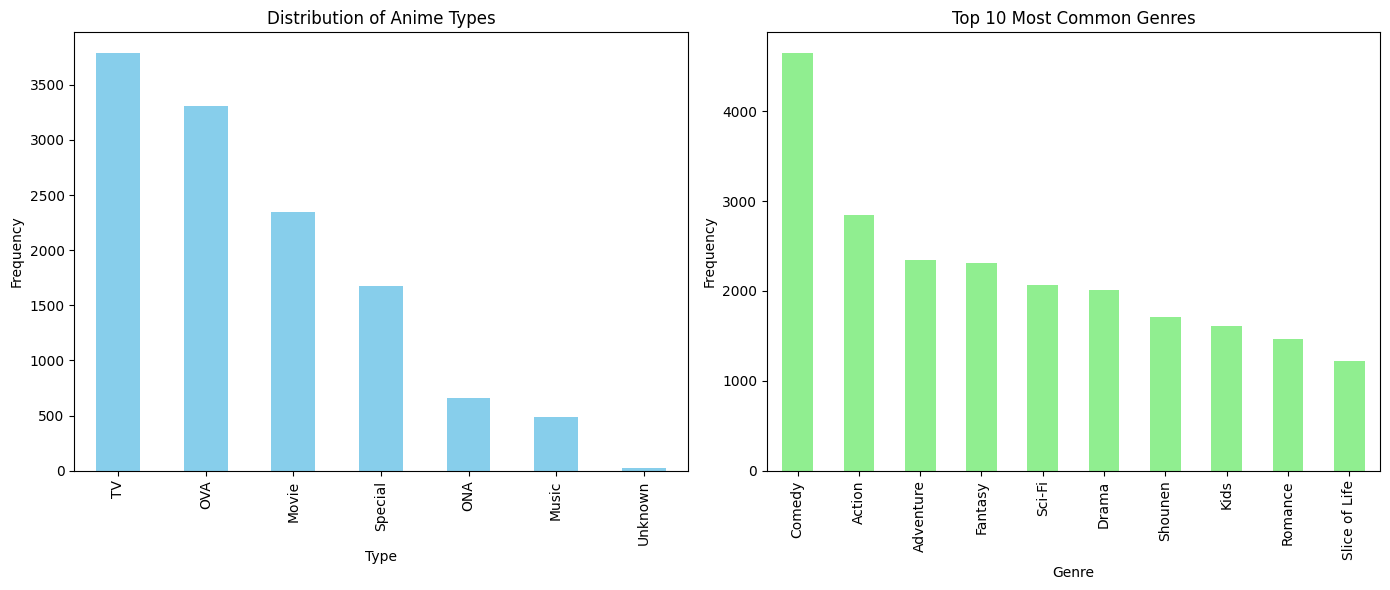

<class 'pandas.core.frame.DataFrame'>
Index: 6337241 entries, 47 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 193.4 MB
6337241
69600
12294
91.05231321839081


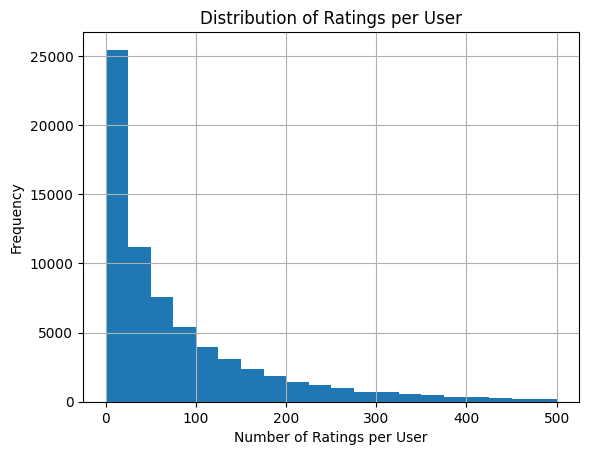

638.3843054296364


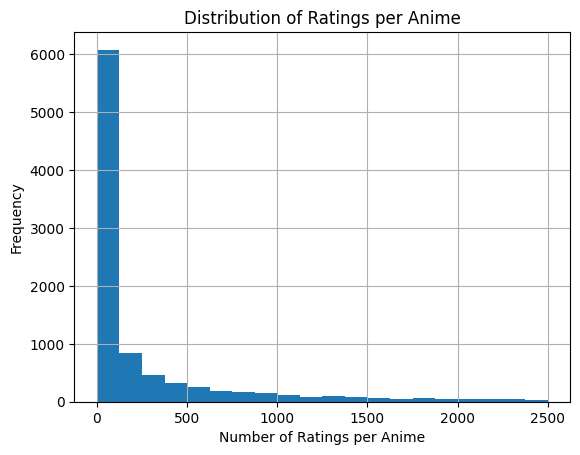

popular_anime 1462
prolific_users 1365
filtered_ratings 1005314
anime_id  1      5      6      7      8      15     16     17     18     \
user_id                                                                   
226         8.0    0.0    8.0    0.0    0.0    0.0    0.0    0.0    0.0   
271         0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
294         7.0    7.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
392         7.0    0.0    7.0    0.0    0.0    0.0    0.0    0.0    7.0   
446         9.0    8.0    9.0    0.0    0.0    0.0    0.0    0.0    0.0   

anime_id  19     ...  34238  34239  34240  34252  34283  34324  34325  34349  \
user_id          ...                                                           
226         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
271         0.0  ...    0.0    0.0   10.0    0.0    0.0    0.0    0.0    0.0   
294         0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
392       

,anime_id,name,genre,type,episodes,rating,members
39,12365,Bakuman. 3rd Season,"Comedy, Drama, Romance, Shounen",TV,25.0,8.71,133620
87,10030,Bakuman. 2nd Season,"Comedy, Drama, Romance, Shounen",TV,25.0,8.53,151561
88,5941,Cross Game,"Comedy, Drama, Romance, School, Sports",TV,50.0,8.53,53108
150,57,Beck,"Comedy, Drama, Music, Shounen, Slice of Life",TV,26.0,8.40,148328
184,7674,Bakuman.,"Comedy, Romance, Shounen",TV,25.0,8.35,246899


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import statistics
import operator

# load the data from 'anime.csv' into a DataFrame named 'animes'.
animes = pd.read_csv('anime.csv')
# Display the first five rows of the DataFrame using the 'head()' method to provide a quick overview of the dataset structure and content.
animes.head()
# Use the 'info()' method to output a concise summary of the DataFrame, including the number of non-null entries in each column, the data type of each column, and memory usage.
animes.info()
# Calculates the total number of missing (null) values in each column using the 'isnull().sum()' method, helping to identify columns that might require cleaning or further investigation due to missing data.
animes.isnull().sum()

# Handle missing values
animes['genre'].fillna('Unknown', inplace=True)
animes['type'].fillna('Unknown', inplace=True)

# Convert the 'episodes' column in the 'animes' dataframe to numeric data type using
# the pd.to_numeric() function, with any non-convertible values replaced by 0
animes['episodes'] = pd.to_numeric(animes['episodes'], errors='coerce').fillna(0)

# Fill missing ratings with mean rating
animes['rating'].fillna(animes['rating'].mean(), inplace=True)

# Generate descriptive statistics for the numerical columns of the 'animes' DataFrame
animes.describe()

# Analyzing categorical variables
type_counts = animes['type'].value_counts()
genre_counts = animes['genre'].str.split(', ').explode().value_counts().head(10)

# Plotting the distributions
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

type_counts.plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Distribution of Anime Types')
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('Type')

genre_counts.plot(kind='bar', ax=ax[1], color='lightgreen')
ax[1].set_title('Top 10 Most Common Genres')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Genre')

plt.tight_layout()
plt.show()

#Exploratory Data Analysis (EDA) on rating dataset

# Read the rating.csv file and store its contents in the 'ratings' dataframe
ratings = pd.read_csv('rating.csv')

# Exclude rows where the rating is -1 (implying missing or few ratings from individuals)
ratings = ratings[ratings.rating != -1]

# Display the first few rows of the filtered ratings dataset
ratings.head()

# Display concise summary information about the 'ratings' DataFrame
ratings.info()
# Count the number of missing values in each column of the 'ratings' DataFrame
ratings.isnull().sum()
# Generate descriptive statistics for the numerical columns of the 'ratings' DataFrame
ratings.describe()
# Calculate the length of the filtered ratings dataset

print(len(ratings))
# Calculate the number of unique user IDs in the filtered ratings dataset
print(len(ratings['user_id'].unique()))

# Calculate the number of unique anime IDs in the 'animes' dataset
print(len(animes['anime_id'].unique()))

# Calculate the number of ratings per user
ratings_per_user = ratings.groupby('user_id')['rating'].count()

# Calculate the mean number of ratings per user
mean_ratings_per_user = statistics.mean(ratings_per_user.tolist())
print(mean_ratings_per_user)

#The average user has rated about 91 items, indicating a moderately active engagement in rating items within the dataset.
#With an average of 91 ratings per user, the dataset shows a balance of user activity that is not skewed by extremely active users.

# Plot a histogram of the number of ratings per user
ratings_per_user.hist(bins=20, range=(0,500))
plt.xlabel('Number of Ratings per User')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings per User')
plt.show()

# Calculate the number of ratings per anime
ratings_per_anime = ratings.groupby('anime_id')['rating'].count()

# Calculate the mean number of ratings per anime
mean_ratings_per_anime = statistics.mean(ratings_per_anime.tolist())
print(mean_ratings_per_anime)

# Plot a histogram of the number of ratings per anime
ratings_per_anime.hist(bins=20, range=(0,2500))
plt.xlabel('Number of Ratings per Anime')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings per Anime')
plt.show()

# Create a DataFrame from the ratings per anime data
ratings_per_anime_df = pd.DataFrame(ratings_per_anime)

# Filter the DataFrame to include only anime with 1000 or more ratings
filtered_ratings_per_anime_df = ratings_per_anime_df[ratings_per_anime_df.rating >= 1000]

# Extract the indices (anime IDs) of popular anime
popular_anime = filtered_ratings_per_anime_df.index.tolist()
print("popular_anime",len(popular_anime))

# Create a DataFrame from the ratings per user data
ratings_per_user_df = pd.DataFrame(ratings_per_user)

# Filter the DataFrame to include only users with 500 or more ratings
filtered_ratings_per_user_df = ratings_per_user_df[ratings_per_user_df.rating >= 500]

# Extract the indices (user IDs) of prolific users
prolific_users = filtered_ratings_per_user_df.index.tolist()
print("prolific_users",len(prolific_users))
# Filter the ratings dataset to include only ratings for popular anime
filtered_ratings = ratings[ratings.anime_id.isin(popular_anime)]

# Further filter the ratings dataset to include only ratings from prolific users
filtered_ratings = ratings[ratings.user_id.isin(prolific_users)]

# Calculate the length of the filtered ratings dataset
print("filtered_ratings",len(filtered_ratings))

# Create a pivot table to construct the user-item rating matrix
rating_matrix = filtered_ratings.pivot_table(index='user_id', columns='anime_id', values='rating')

# Fill missing values (NaN) with 0
rating_matrix = rating_matrix.fillna(0)

# Display the first few rows of the user-item rating matrix
print(rating_matrix.head())
'''
The user-item rating matrix indicates the interactions between users and items
in the form of ratings. Each row represents a user, each column represents
an anime title, and the values in the matrix represent the ratings given
by users to the corresponding anime titles.
This matrix provides a structured representation of user preferences and
behaviors, serving as the foundation for collaborative filtering techniques to
generate personalized recommendations.
'''
#Define a function to find similar_users based on the cosine similarity of their rating vectors.

def similar_users(user_id, matrix, k=3):
    # Retrieve the user's vector from the rating matrix
    user = matrix[matrix.index == user_id]

    # Exclude the user's vector from the rating matrix
    other_users = matrix[matrix.index != user_id]

    # Calculate cosine similarity between the user and other users
    similarities = cosine_similarity(user, other_users)[0].tolist()

    # Get the indices (user IDs) of other users
    indices = other_users.index.tolist()

    # Create a dictionary mapping indices to similarity scores
    index_similarity = dict(zip(indices, similarities))

    # Sort the dictionary by similarity scores in descending order
    index_similarity_sorted = sorted(index_similarity.items(), key=operator.itemgetter(1))
    index_similarity_sorted.reverse()

    # Get the top k similar users
    top_users_similarities = index_similarity_sorted[:k]
    users = [u[0] for u in top_users_similarities]

    return users

#Test the similar_users function with a sample user ID.
# Define the current user's ID
current_user = 226

# Find indices of similar users to the current user
similar_user_indices = similar_users(current_user, rating_matrix)

# Print the indices of similar users
print(similar_user_indices)

def recommend_item(user_index, similar_user_indices, matrix, items=5):
    # Select rows corresponding to similar users
    similar_users = matrix[matrix.index.isin(similar_user_indices)]

    # Calculate the mean rating for each item among similar users
    similar_users = similar_users.mean(axis=0)

    # Convert the result to a DataFrame
    similar_users_df = pd.DataFrame(similar_users, columns=['mean'])

    # Select the target user's ratings
    user_df = matrix[matrix.index == user_index]

    # Transpose the DataFrame for easier manipulation
    user_df_transposed = user_df.transpose()

    # Rename the column for clarity
    user_df_transposed.columns = ['rating']

    # Filter out items that the target user has already rated
    user_df_transposed = user_df_transposed[user_df_transposed['rating']==0]

    # Extract the indices (anime IDs) of unseen items
    animes_unseen = user_df_transposed.index.tolist()

    # Filter the DataFrame to include only ratings for unseen items
    similar_users_df_filtered = similar_users_df[similar_users_df.index.isin(animes_unseen)]

    # Sort the DataFrame by mean rating in descending order
    similar_users_df_ordered = similar_users_df_filtered.sort_values(by=['mean'], ascending=False)

    # Select the top n items with the highest mean rating
    top_n_anime = similar_users_df_ordered.head(items)
    top_n_anime_indices = top_n_anime.index.tolist()

    # Retrieve information about the recommended anime from the 'animes' dataset
    anime_information = animes[animes['anime_id'].isin(top_n_anime_indices)]

    return anime_information

recommend_item(226, similar_user_indices, rating_matrix)